## Polyak descent / Stochastic Polyak step (SPS) for Variational Quantum Optimization



>  Implementing Polyak descent / Stochastic Polyak step**
> For this set `f* = optimal` (compute this before). `f* = 0`, and `f* = larger/smaller than optimal`.

- **Ansatz:** `Rx, Ry` then linear CNOT gates (for each layer)
- **Objective:** `H = -sum(Z_i Z_{i+1}) - sum(X_i)`  (transverse-field Ising model, TFIM)
- Start with 2 qubits 2 layers and scale up
- Compare with **Adam, SGD, and QNG**

**Notes:** results are *not* supposed to be better — ideally worse. The goal is to see whether these methods *work at all*, before improving them next week.

**The Polyak step:**
$$\eta_k = \frac{f(\theta_k) - f^\star}{\lVert\nabla f(\theta_k)\rVert^2},\qquad \theta_{k+1} = \theta_k - \eta_k\,\nabla f(\theta_k)$$

We sweep `f*` over four regimes to expose how sensitive Polyak is to knowing `f*`:

| Regime | Setting | Meaning |
|---|---|---|
| `optimal`       | `f* = E0`          | exact ground-state energy — the ideal Polyak target |
| `zero`          | `f* = 0`           | an OVER-estimate, since `E0 < 0` for the TFIM |
| `lower (under)` | `f* = E0 - buffer` | a valid LOWER bound → step over-shoots but stays well-defined |
| `higher (over)` | `f* = E0 + buffer` | an OVER-estimate → numerator goes negative near the bottom |

This is a **deterministic (exact-expectation / infinite-shot)** study: `f(theta)` is computed analytically by the simulator, so "SPS" here reduces to the full-batch Polyak step. Shot noise / debiasing (Eq. 9 of the draft) is intentionally out of scope for Task 2.

## 0. Imports & setup

In [1]:
import os
import time
import numpy as np
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt

RESULTS_DIR = os.path.join(os.path.abspath(""), "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

## 1. Hamiltonian:  $H = -\sum_i Z_i Z_{i+1} - \sum_i X_i$   (open-boundary TFIM)

In [2]:
def build_tfim(n_qubits):
    coeffs, ops = [], []
    # -ZZ on nearest neighbours (open / linear chain, matching the linear CNOT ansatz)
    for i in range(n_qubits - 1):
        coeffs.append(-1.0)
        ops.append(qml.PauliZ(i) @ qml.PauliZ(i + 1))
    # -X transverse field on every qubit
    for i in range(n_qubits):
        coeffs.append(-1.0)
        ops.append(qml.PauliX(i))
    return qml.Hamiltonian(coeffs, ops)


def exact_ground_energy(H):
    """f* = optimal: smallest eigenvalue of H via exact diagonalisation."""
    Hmat = qml.matrix(H)
    eigvals = np.linalg.eigvalsh(Hmat)
    return float(np.min(eigvals)), float(np.max(eigvals))

## 2. Ansatz:  per layer → `Rx, Ry` on each qubit, then a linear chain of CNOTs

In [3]:
def make_cost(n_qubits, n_layers, H):
    dev = qml.device("default.qubit", wires=n_qubits)

    def ansatz(params):
        # params shape: (n_layers, n_qubits, 2)  -> [Rx angle, Ry angle]
        for layer in range(n_layers):
            for w in range(n_qubits):
                qml.RX(params[layer, w, 0], wires=w)
                qml.RY(params[layer, w, 1], wires=w)
            for w in range(n_qubits - 1):           # linear CNOT chain
                qml.CNOT(wires=[w, w + 1])

    @qml.qnode(dev, interface="autograd")
    def cost(params):
        ansatz(params)
        return qml.expval(H)

    return cost


def init_params(n_qubits, n_layers, seed=SEED):
    rng = np.random.default_rng(seed)
    p = rng.uniform(0, 2 * np.pi, size=(n_layers, n_qubits, 2))
    return pnp.array(p, requires_grad=True)


## 3. Optimisers

`run_polyak` runs with the fixed-LR helper wraps Adam/SGD, and `run_qng` is the quantum-natural-gradient baseline.

In [4]:
def run_polyak(cost, params, f_star, n_steps, eta_max=10.0, eps=1e-12):
    """Polyak step: eta_k = (f - f*) / ||grad||^2 (clipped to eta_max for stability)."""
    grad_fn = qml.grad(cost)
    history, etas = [], []
    p = params.copy()
    for _ in range(n_steps):
        f = float(cost(p))
        g = grad_fn(p)
        gnorm2 = float(np.sum(g * g))
        history.append(f)
        eta = (f - f_star) / (gnorm2 + eps)
        eta = float(np.clip(eta, -eta_max, eta_max))   # allow negative to expose the failure mode
        etas.append(eta)
        p = p - eta * g
    history.append(float(cost(p)))
    return np.array(history), np.array(etas), p


def run_fixed_lr(cost, params, n_steps, optimizer):
    history = []
    p = params.copy()
    for _ in range(n_steps):
        p, f = optimizer.step_and_cost(cost, p)
        history.append(float(f))
    history.append(float(cost(p)))
    return np.array(history), p


def run_qng(cost, params, n_steps, stepsize=0.1):
    opt = qml.QNGOptimizer(stepsize=stepsize)
    history = []
    p = params.copy()
    for _ in range(n_steps):
        p, f = opt.step_and_cost(cost, p)
        history.append(float(f))
    history.append(float(cost(p)))
    return np.array(history), p

## 4. Plotting

In [5]:
def plot_runs(runs, E0, n_qubits, n_layers):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
    for label, hist in runs.items():
        ax1.plot(hist, label=label, lw=1.8)
    ax1.axhline(E0, color="k", ls="--", lw=1, label=f"E0 = {E0:.3f}")
    ax1.set_xlabel("iteration"); ax1.set_ylabel("energy  <H>")
    ax1.set_title(f"Energy vs iteration ({n_qubits}q, {n_layers}L TFIM)")
    ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

    for label, hist in runs.items():
        err = np.abs(np.array(hist) - E0) + 1e-12
        ax2.semilogy(err, label=label, lw=1.8)
    ax2.set_xlabel("iteration"); ax2.set_ylabel("|E - E0|  (log)")
    ax2.set_title("Energy error to exact ground state")
    ax2.legend(fontsize=7); ax2.grid(alpha=0.3, which="both")

    fig.tight_layout()
    fname = os.path.join(RESULTS_DIR, f"task2_polyak_{n_qubits}q_{n_layers}L.png")
    fig.savefig(fname, dpi=130)
    print(f"  -> saved plot: {fname}")
    plt.show()

## 5. Experiment

Builds the TFIM, computes the exact ground energy `E0` (the ideal `f*`), runs the four Polyak regimes plus the Adam / SGD / QNG baselines, and plots.

In [6]:
def run_experiment(n_qubits=2, n_layers=2, n_steps=120):
    print(f"\n{'='*70}\nTFIM  n_qubits={n_qubits}  n_layers={n_layers}  steps={n_steps}\n{'='*70}")
    H = build_tfim(n_qubits)
    E0, Emax = exact_ground_energy(H)
    spectral_range = Emax - E0
    buffer = 0.25 * spectral_range
    print(f"Exact ground-state energy  E0 (= f* optimal) = {E0:.6f}")
    print(f"Largest eigenvalue         Emax             = {Emax:.6f}")

    cost = make_cost(n_qubits, n_layers, H)
    p0 = init_params(n_qubits, n_layers)
    print(f"Initial energy f(theta_0) = {float(cost(p0)):.6f}\n")

    runs = {}

    # ---- Polyak variants (the focus of Task 2) -------------------------------
    polyak_targets = {
        "Polyak f*=E0 (optimal)":        E0,
        "Polyak f*=0":                   0.0,
        "Polyak f*=E0-buf (lower bnd)":  E0 - buffer,
        "Polyak f*=E0+buf (over-est)":   E0 + buffer,
    }
    for label, fstar in polyak_targets.items():
        hist, etas, _ = run_polyak(cost, p0, fstar, n_steps)
        runs[label] = hist
        print(f"{label:32s} final E = {hist[-1]: .6f}   |err|={abs(hist[-1]-E0):.3e}   "
              f"eta[min,max]=[{etas.min():.2f},{etas.max():.2f}]")

    # ---- Baselines -----------------------------------------------------------
    hist, _ = run_fixed_lr(cost, p0, n_steps, qml.AdamOptimizer(stepsize=0.1))
    runs["Adam (lr=0.1)"] = hist
    print(f"{'Adam (lr=0.1)':32s} final E = {hist[-1]: .6f}   |err|={abs(hist[-1]-E0):.3e}")

    hist, _ = run_fixed_lr(cost, p0, n_steps, qml.GradientDescentOptimizer(stepsize=0.1))
    runs["SGD (lr=0.1)"] = hist
    print(f"{'SGD (lr=0.1)':32s} final E = {hist[-1]: .6f}   |err|={abs(hist[-1]-E0):.3e}")

    try:
        hist, _ = run_qng(cost, p0, n_steps, stepsize=0.1)
        runs["QNG (lr=0.1)"] = hist
        print(f"{'QNG (lr=0.1)':32s} final E = {hist[-1]: .6f}   |err|={abs(hist[-1]-E0):.3e}")
    except Exception as e:
        print(f"QNG failed: {e}")

    plot_runs(runs, E0, n_qubits, n_layers)
    return runs, E0

## 6. Run — start small (2q/2L), then scale up

As the task asks, begin at 2 qubits / 2 layers and scale to as many qubits / layers as feasible.

In [ ]:
runs_2q2L, E0_2q2L = run_experiment(n_qubits=2, n_layers=2, n_steps=120)


TFIM  n_qubits=2  n_layers=2  steps=120
Exact ground-state energy  E0 (= f* optimal) = -2.236068
Largest eigenvalue         Emax             = 2.236068
Initial energy f(theta_0) = 1.046980

Polyak f*=E0 (optimal)           final E = -2.236068   |err|=7.301e-13   eta[min,max]=[0.15,4.27]
Polyak f*=0                      final E = -0.000000   |err|=2.236e+00   eta[min,max]=[-0.05,0.41]
Polyak f*=E0-buf (lower bnd)     final E = -2.129117   |err|=1.070e-01   eta[min,max]=[0.43,10.00]



TFIM  n_qubits=2  n_layers=4  steps=120
Exact ground-state energy  E0 (= f* optimal) = -2.236068
Largest eigenvalue         Emax             = 2.236068
Initial energy f(theta_0) = -0.624521

Polyak f*=E0 (optimal)           final E = -2.236068   |err|=4.885e-15   eta[min,max]=[0.00,0.36]
Polyak f*=0                      final E = -0.000000   |err|=2.236e+00   eta[min,max]=[-0.14,0.00]
Polyak f*=E0-buf (lower bnd)     final E = -1.186441   |err|=1.050e+00   eta[min,max]=[0.13,10.00]
Polyak f*=E0+buf (over-est)      final E = -1.118034   |err|=1.118e+00   eta[min,max]=[0.00,0.11]
Adam (lr=0.1)                    final E = -2.236066   |err|=1.741e-06
SGD (lr=0.1)                     final E = -2.236068   |err|=5.329e-15
QNG (lr=0.1)                     final E = -2.236062   |err|=5.783e-06
  -> saved plot: c:\Users\lpand003\Desktop\Projects\research_papers\quantum_reinforcement_learning_papers\polyak_vqa\learning_rate\results\task2_polyak_2q_4L.png


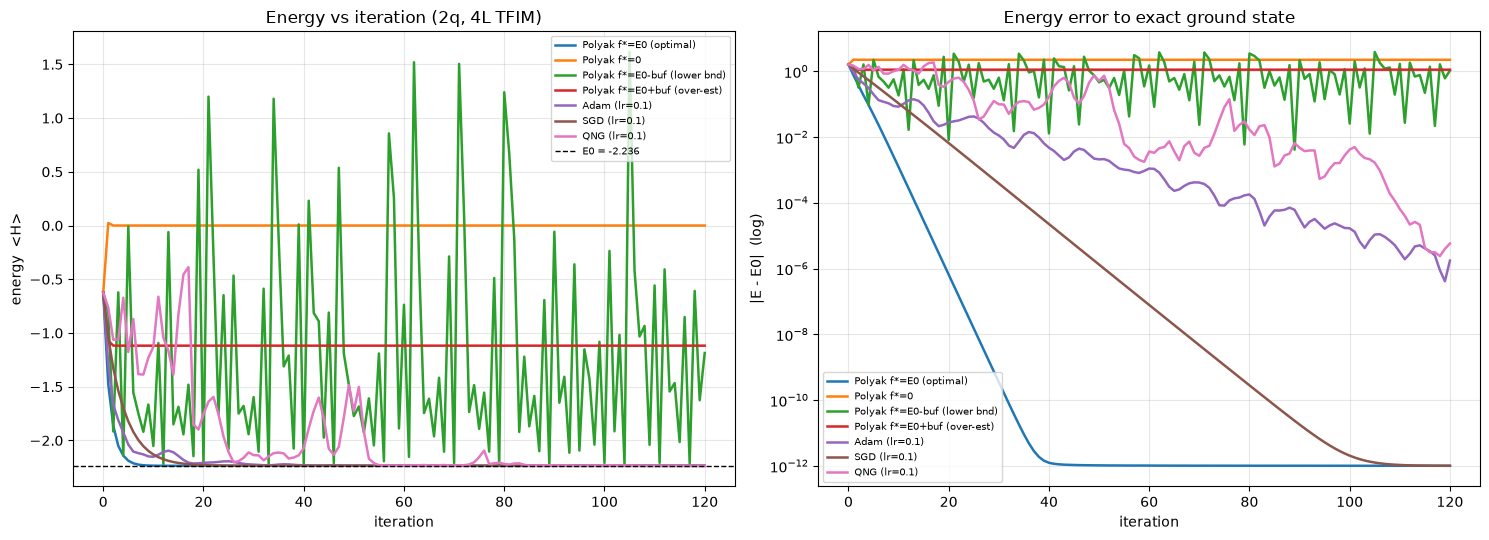

In [ ]:
runs_2q2L, E0_2q2L = run_experiment(n_qubits=2, n_layers=4, n_steps=120)


TFIM  n_qubits=4  n_layers=2  steps=150
Exact ground-state energy  E0 (= f* optimal) = -4.758770
Largest eigenvalue         Emax             = 4.758770
Initial energy f(theta_0) = -0.633122

Polyak f*=E0 (optimal)           final E = -4.756654   |err|=2.117e-03   eta[min,max]=[0.17,10.00]
Polyak f*=0                      final E = -0.000000   |err|=4.759e+00   eta[min,max]=[-0.18,-0.00]
Polyak f*=E0-buf (lower bnd)     final E = -1.153797   |err|=3.605e+00   eta[min,max]=[0.49,5.61]
Polyak f*=E0+buf (over-est)      final E = -2.379385   |err|=2.379e+00   eta[min,max]=[-0.02,0.49]
Adam (lr=0.1)                    final E = -4.757414   |err|=1.357e-03
SGD (lr=0.1)                     final E = -4.757359   |err|=1.412e-03
QNG (lr=0.1)                     final E = -4.699956   |err|=5.881e-02
  -> saved plot: c:\Users\lpand003\Desktop\Projects\research_papers\quantum_reinforcement_learning_papers\polyak_vqa\learning_rate\results\task2_polyak_4q_2L.png


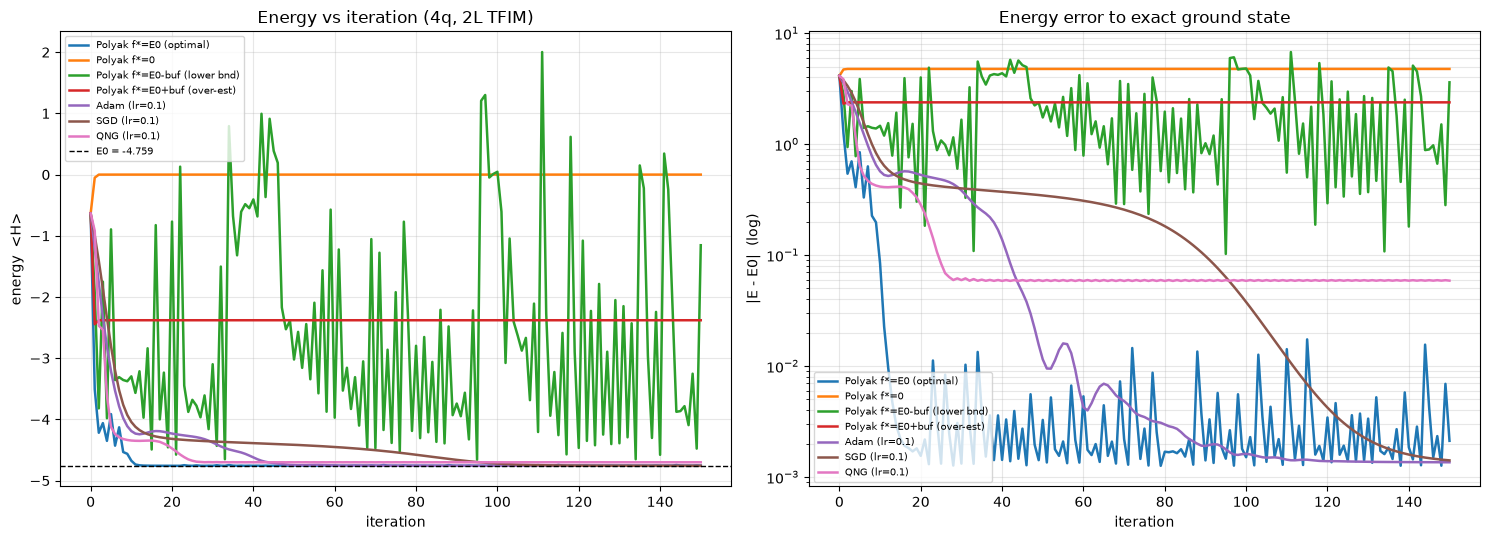

In [ ]:
runs_4q2L, E0_4q2L = run_experiment(n_qubits=4, n_layers=2, n_steps=150)


TFIM  n_qubits=4  n_layers=4  steps=150
Exact ground-state energy  E0 (= f* optimal) = -4.758770
Largest eigenvalue         Emax             = 4.758770
Initial energy f(theta_0) = -0.038141

Polyak f*=E0 (optimal)           final E = -4.757867   |err|=9.037e-04   eta[min,max]=[0.06,10.00]
Polyak f*=0                      final E =  0.000000   |err|=4.759e+00   eta[min,max]=[-0.00,0.00]
Polyak f*=E0-buf (lower bnd)     final E = -1.519072   |err|=3.240e+00   eta[min,max]=[0.26,6.64]
Polyak f*=E0+buf (over-est)      final E = -2.379385   |err|=2.379e+00   eta[min,max]=[0.00,0.24]
Adam (lr=0.1)                    final E = -4.758742   |err|=2.843e-05
SGD (lr=0.1)                     final E = -4.755887   |err|=2.884e-03
QNG (lr=0.1)                     final E = -4.490469   |err|=2.683e-01
  -> saved plot: c:\Users\lpand003\Desktop\Projects\research_papers\quantum_reinforcement_learning_papers\polyak_vqa\learning_rate\results\task2_polyak_4q_4L.png


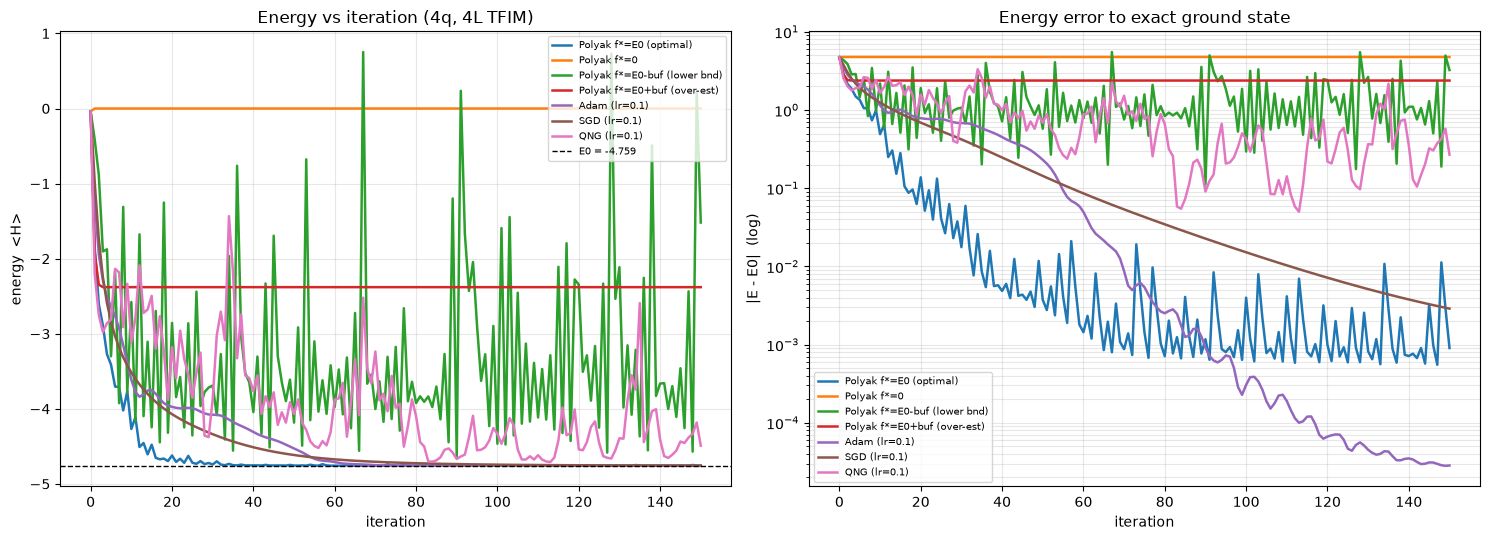

In [ ]:
runs_4q4L, E0_4q4L = run_experiment(n_qubits=4, n_layers=4, n_steps=150)



- **`f*=E0` (optimal)** and **`f*=E0-buf` (valid lower bound)** should descend cleanly toward `E0` (the lower bound converges to a neighbourhood, not exactly).
- **`f*=E0+buf` (over-estimate)** and **`f*=0`** should stall / oscillate above `E0` — once the energy drops below `f*` the numerator goes negative and the step pushes *uphill*.

